In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import yaml
idx = pd.IndexSlice

In [44]:
with open(
    Path.cwd().parent / 'config' / 'plotting.default.yaml', 'r'
) as f:
    tech_colors = yaml.safe_load(f)['plotting']['tech_colors']

In [45]:
bal = pd.read_csv(
    Path.cwd().parent  / 'results' / 'csvs' / 'energy_balance.csv', header=list(range(5)), index_col=[0,1,2]
)
bal.columns = bal.columns.get_level_values(-1).astype(int)
bal.head()

wiggle                                                  0             250   \
component carrier                  bus_carrier                               
Generator Offshore Wind (AC)       AC           2.918550e+08  2.563997e+08   
          Offshore Wind (DC)       AC           3.010948e+08  2.839668e+08   
          Offshore Wind (Floating) AC           7.469356e+02  6.748944e+02   
          Onshore Wind             AC           1.024939e+09  1.034054e+09   
          Run of River             AC           1.605181e+08  1.605832e+08   

wiggle                                                  500           750   \
component carrier                  bus_carrier                               
Generator Offshore Wind (AC)       AC           2.420462e+08  2.363675e+08   
          Offshore Wind (DC)       AC           2.764314e+08  2.588663e+08   
          Offshore Wind (Floating) AC           2.774986e+02  4.615355e+02   
          Onshore Wind             AC           9.627309e+08  8.774669e+08   
          Run of River             AC           1.610183e+08  1.608973e+08   

wiggle                                                  1000          1250  \
component carrier                  bus_carrier                               
Generator Offshore Wind (AC)       AC           2.357253e+08  2.363496e+08   
          Offshore Wind (DC)       AC           2.287777e+08  2.250767e+08   
          Offshore Wind (Floating) AC           6.642749e+02  4.735964e+02   
          Onshore Wind             AC           8.418261e+08  7.996371e+08   
          Run of River             AC           1.613242e+08  1.617309e+08   

wiggle                                                  1500          1750  \
component carrier                  bus_carrier                               
Generator Offshore Wind (AC)       AC           2.314669e+08  2.367359e+08   
          Offshore Wind (DC)       AC           2.297178e+08  2.222453e+08   
          Offshore Wind (Floating) AC           7.106848e+02  6.935899e+02   
          Onshore Wind             AC           7.736297e+08  7.394033e+08   
          Run of River             AC           1.619653e+08  1.619542e+08   

wiggle                                                  2000          2250  \
component carrier                  bus_carrier                               
Generator Offshore Wind (AC)       AC           2.356687e+08  2.352737e+08   
          Offshore Wind (DC)       AC           2.132387e+08  2.068756e+08   
          Offshore Wind (Floating) AC           6.936563e+02  5.055282e+02   
          Onshore Wind             AC           7.108103e+08  6.888042e+08   
          Run of River             AC           1.618019e+08  1.618685e+08   

wiggle                                          ...          2750  \
component carrier                  bus_carrier  ...                 
Generator Offshore Wind (AC)       AC           ...  2.275130e+08   
          Offshore Wind (DC)       AC           ...  1.621367e+08   
          Offshore Wind (Floating) AC           ...  2.864092e+02   
          Onshore Wind             AC           ...  6.443047e+08   
          Run of River             AC           ...  1.620468e+08   

wiggle                                                  3000          3250  \
component carrier                  bus_carrier                               
Generator Offshore Wind (AC)       AC           2.303645e+08  2.320342e+08   
          Offshore Wind (DC)       AC           1.312410e+08  8.509936e+07   
          Offshore Wind (Floating) AC           5.997836e+02  3.091148e+02   
          Onshore Wind             AC           6.251590e+08  6.210625e+08   
          Run of River             AC           1.622232e+08  1.623575e+08   

wiggle                                                  3500          3750  \
component carrier                  bus_carrier                               
Generator Offshore Wind (AC)       AC           2.289933e+08  2.166289e+08   


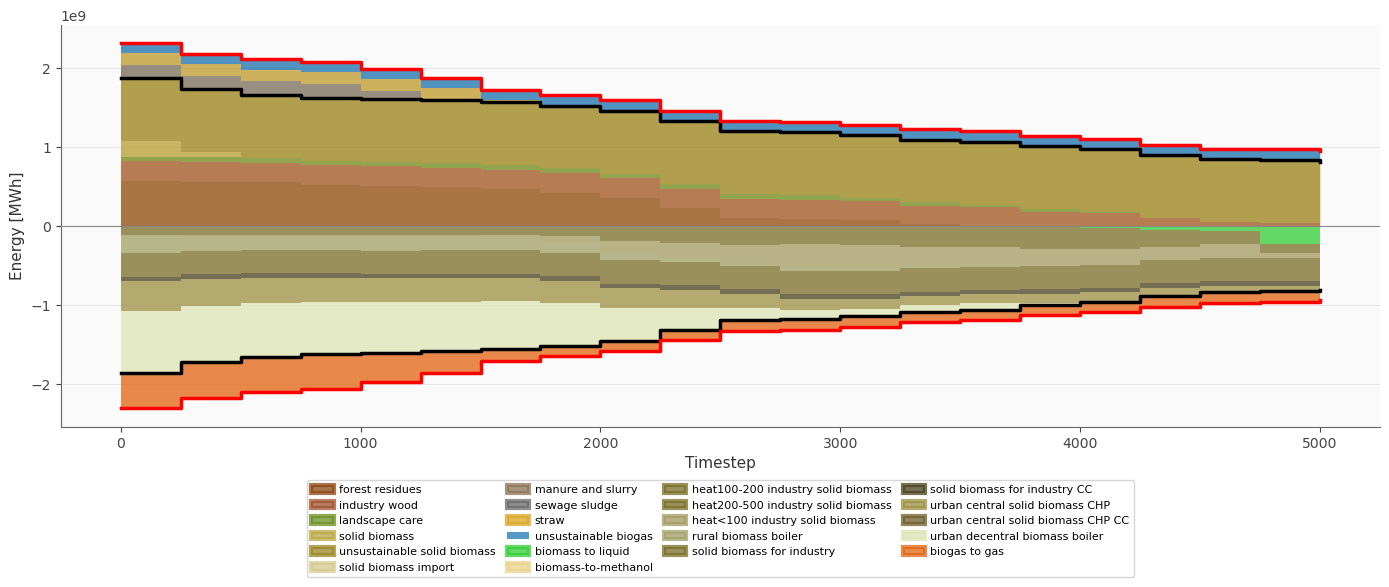

In [55]:
fig, ax = plt.subplots(figsize=(14, 6))

# --- Style setup ---
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('white')
ax.grid(axis='y', color='#dddddd', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#666666')
ax.spines['bottom'].set_color('#666666')
ax.tick_params(colors='#444444', labelsize=10)

from matplotlib.patches import Patch
producer_handles = []
producer_labels = []
consumer_handles = []
consumer_labels = []

# =====================
# Gather both datasets
# =====================
bg_idx = 'biogas'
df_bg = bal.loc[idx[:, :, bg_idx]].droplevel(0)

bm_idx = 'solid biomass'
df_bm = bal.loc[idx[:, :, bm_idx]].droplevel(0)

# =====================
# Running offsets for true stacking
# =====================
# For correct stacking, use the same axis order for x as before.
cols = df_bg.columns  # assume same columns

offset_pos = pd.Series(0.0, index=cols)
offset_neg = pd.Series(0.0, index=cols)

# To avoid duplicate legend entries
used_for_area = {}

def add_legend_handle(tech, color, group):
    if tech not in used_for_area:
        handle = Patch(facecolor=color, edgecolor=color, label=tech, linewidth=3, alpha=0.75)
        if group == "producer":
            producer_handles.append(handle)
            producer_labels.append(tech)
        else:
            consumer_handles.append(handle)
            consumer_labels.append(tech)
        used_for_area[tech] = True

# --- Plot solid biomass techs first (bottom of stack) ---
for tech in df_bm.index.unique(0):
    data = df_bm.loc[tech]
    color = tech_colors.get(tech, None)
    pos = data.clip(lower=0)
    neg = data.clip(upper=0)

    if (pos > 0).any():
        h = ax.fill_between(
            cols, offset_pos.values + pos.values, offset_pos.values,
            color=color, alpha=0.75, linewidth=0.3, edgecolor='none', step='post'
        )
        add_legend_handle(tech, color, "producer")
        offset_pos += pos.values

    if (neg < 0).any():
        h = ax.fill_between(
            cols, offset_neg.values + neg.values, offset_neg.values,
            color=color, alpha=0.75, linewidth=0.3, edgecolor='none', step='post'
        )
        # Only add negative-only to consumers if not also a producer
        if not (pos > 0).any():
            add_legend_handle(tech, color, "consumer")
        offset_neg += neg.values

# Solid biomass aggregate line (snapshot of offset after solid biomass)
agg_bm_pos = offset_pos.copy()
agg_bm = df_bm.sum(axis=0)

ax.plot(
    cols, agg_bm_pos.values,
    color=tech_colors.get('solid_biomass_agg', 'k'),
    lw=2.5, zorder=5, drawstyle='steps-post'
)
ax.plot(
    cols, -agg_bm_pos.values,
    color=tech_colors.get('solid_biomass_agg', 'k'),
    lw=2.5, zorder=5, drawstyle='steps-post'
)

# --- Plot biogas techs on top ---
for tech in df_bg.index.unique(0):
    data = df_bg.loc[tech]
    color = tech_colors.get(tech, None)
    pos = data.clip(lower=0)
    neg = data.clip(upper=0)

    if (pos > 0).any():
        h = ax.fill_between(
            cols, offset_pos.values + pos.values, offset_pos.values,
            color=color, alpha=0.75, linewidth=0.3, edgecolor='none', step='post'
        )
        add_legend_handle(tech, color, "producer")
        offset_pos += pos.values

    if (neg < 0).any():
        h = ax.fill_between(
            cols, offset_neg.values + neg.values, offset_neg.values,
            color=color, alpha=0.75, linewidth=0.3, edgecolor='none', step='post'
        )
        if not (pos > 0).any():
            add_legend_handle(tech, color, "consumer")
        offset_neg += neg.values

# Biogas aggregate line (top of full stack)
agg_total = offset_pos.copy()

ax.plot(
    cols, agg_total.values,
    color=tech_colors.get('biogas_agg', 'red'),
    lw=2.5, zorder=5, drawstyle='steps-post'
)
ax.plot(
    cols, -agg_total.values,
    color=tech_colors.get('biogas_agg', 'red'),
    lw=2.5, zorder=5, drawstyle='steps-post'
)

# --- Shaded aggregate bands ---
ax.fill_between(
    cols, agg_bm_pos.values, 0,
    color=tech_colors.get('solid_biomass_agg', '#B8860B'),
    alpha=0.12, zorder=1, step='post'
)
ax.fill_between(
    cols, agg_total.values, agg_bm_pos.values,
    color=tech_colors.get('biogas_agg', '#20639B'),
    alpha=0.10, zorder=2, step='post'
)

# --- Legend ---
final_handles = producer_handles + consumer_handles
final_labels = producer_labels + consumer_labels

ax.legend(
    final_handles, final_labels,
    loc='upper center', bbox_to_anchor=(0.5, -0.12),
    ncol=4, fontsize=8, frameon=True, fancybox=True,
    shadow=False, edgecolor='#cccccc',
    columnspacing=1.0, handletextpad=0.5
)

ax.set_xlabel("Timestep", fontsize=11, color='#333333')
ax.set_ylabel("Energy [MWh]", fontsize=11, color='#333333')
ax.axhline(0, color='#888888', linewidth=0.8, zorder=3)

plt.tight_layout()
plt.subplots_adjust(bottom=0.28)
plt.show()

In [56]:
producer_labels

['forest residues',
 'industry wood',
 'landscape care',
 'solid biomass',
 'unsustainable solid biomass',
 'solid biomass import',
 'manure and slurry',
 'sewage sludge',
 'straw',
 'unsustainable biogas']

In [57]:
consumer_labels

['biomass to liquid',
 'biomass-to-methanol',
 'heat100-200 industry solid biomass',
 'heat200-500 industry solid biomass',
 'heat<100 industry solid biomass',
 'rural biomass boiler',
 'solid biomass for industry',
 'solid biomass for industry CC',
 'urban central solid biomass CHP',
 'urban central solid biomass CHP CC',
 'urban decentral biomass boiler',
 'biogas to gas']

Index(['AC', 'co2', 'coal', 'solid biomass', 'gas', 'biogas',
       'municipal solid waste', 'oil primary', 'rural heat',
       'unsustainable bioliquids', 'urban central heat',
       'urban decentral heat', 'EV battery', 'low voltage', 'steel',
       'steel emission', 'hbi', 'Hydrogen Storage', 'co2 stored', 'oil',
       'non-sequestered HVC', 'NH3', 'methanol', 'agriculture machinery oil',
       'Battery Storage', 'co2 sequestered', 'coal for industry',
       'gas for industry', 'heat100-200 industry', 'heat200-500 industry',
       'heat<100 industry', 'heat>500 industry', 'home battery',
       'kerosene for aviation', 'land transport oil', 'naphtha for industry',
       'shipping methanol', 'shipping oil', 'solid biomass for industry',
       'solid biomass import'],
      dtype='object', name='bus_carrier')

In [19]:
bal.loc[idx[:,:,'solid biomass']].index.unique(1)

Index(['forest residues', 'industry wood', 'landscape care', 'solid biomass',
       'unsustainable solid biomass', 'biomass to liquid',
       'biomass-to-methanol', 'heat100-200 industry solid biomass',
       'heat200-500 industry solid biomass', 'heat<100 industry solid biomass',
       'rural biomass boiler', 'solid biomass for industry',
       'solid biomass for industry CC', 'solid biomass import',
       'urban central solid biomass CHP', 'urban central solid biomass CHP CC',
       'urban decentral biomass boiler'],
      dtype='object', name='carrier')

In [20]:
bal.loc[idx[:,:,'biogas']].index.unique(1)

Index(['manure and slurry', 'sewage sludge', 'straw', 'unsustainable biogas',
       'biogas to gas'],
      dtype='object', name='carrier')